#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN Lab 03                                                                          
***Date:*** 12/02/2026

#**Task 01**

###**Part A: Understanding the Problem**
**1.What type of machine learning problem is this?**
>This is a binary classification problem because the model is predicting one of two discrete classes: Low Risk (0) or High Risk (1).

**2.Why is sigmoid activation appropriate for the output layer?**
>Sigmoid is appropriate because it squashes the output into a range between 0 and 1, which can be interpreted as the probability of the patient being "High Risk".

**3.If the relationship between BMI and heart rate is nonlinear, which model would likely perform better?**
>The Multi-Layer Perceptron (MLP) would perform better because hidden layers allow the model to learn complex, nonlinear decision boundaries that a single-layer model cannot

**4.Mathematically, what does a single Dense(1, sigmoid) layer compute?**
>It computes the weighted sum of inputs plus a bias, passed through the sigmoid function: $\hat{y} = \sigma(w_1x_1 + w_2x_2 + b)$

###**Part B: Data Preparation**
Here is the code to set up your environment and generate the health startup's synthetic data.

In [1]:
# Step 1: Import necessary libraries for data generation, scaling, and modeling
import tensorflow as tf
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 2: Generate a synthetic dataset representing Heart Rate and BMI for 1000 patients
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_classes=2, random_state=42)

# Step 3: Print the first 5 rows of features to inspect the heart rate and BMI data
print("First 5 rows of features:\n", X[:5])

# Step 4: Check the class distribution to ensure there is a balance between Low Risk and High Risk samples
print("Class distribution:", np.bincount(y))

# Step 5: Split data into training (80%) and testing (20%) sets to evaluate model performance later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Initialize the StandardScaler to normalize feature ranges for better neural network convergence
scaler = StandardScaler()

# Step 7: Fit the scaler on training data and transform both sets to ensure features have zero mean and unit variance
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

First 5 rows of features:
 [[-0.99910178 -0.66386   ]
 [ 1.24668618  1.15359685]
 [ 0.96277683  0.85939747]
 [-2.95744095  2.03364529]
 [ 1.14116527  1.05944863]]
Class distribution: [498 502]


**Why scaling is necessary for neural networks:**

Neural networks are highly sensitive to the scale of input features; without scaling, one feature (like heart rate) might dominate the weight updates, leading to slow convergence or unstable gradients

###**Part C – Model 1: Single-Layer Perceptron**

In [2]:
# Step 1: Define the SLP architecture with one dense layer containing a single neuron and sigmoid activation [cite: 115, 116, 226]
model_slp = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(2,))
])

# Step 2: Compile the model using the SGD optimizer and binary crossentropy loss function [cite: 126, 127, 128, 226]
model_slp.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# Step 3: Train the model for 50 epochs while holding out 10% of training data for validation [cite: 138, 140, 142, 226]
history_slp = model_slp.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# Step 4: Evaluate the trained model on the unseen test dataset to determine final performance [cite: 152, 227]
loss_slp, acc_slp = model_slp.evaluate(X_test, y_test, verbose=0)

# Step 5: Extract and print the required metrics for the final lab report
print(f"Final Loss Value: {loss_slp:.4f}")
print(f"Training Accuracy: {history_slp.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy: {history_slp.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {acc_slp:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4467 - loss: 0.8162 - val_accuracy: 0.5000 - val_loss: 0.7344
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4703 - loss: 0.7324 - val_accuracy: 0.5250 - val_loss: 0.6801
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4731 - loss: 0.6795 - val_accuracy: 0.5375 - val_loss: 0.6377
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5041 - loss: 0.6321 - val_accuracy: 0.6875 - val_loss: 0.6050
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6426 - loss: 0.5903 - val_accuracy: 0.8000 - val_loss: 0.5798
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8079 - loss: 0.5372 - val_accuracy: 0.8000 - val_loss: 0.5603
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8544 - loss: 0.5272 - val_accuracy: 0.7625 - val_loss: 0.5450
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8538 - loss: 0.4957 - val_accuracy: 0.7625 - val_l

###**Explanation of Components:**
>**One Neuron:** Represents a single decision unit that calculates a weighted sum of the inputs.

>**Sigmoid Activation:** Squashes the output to a $(0, 1)$ range, making it suitable for binary classification tasks.

>**SGD Optimizer:** Updates weights using Stochastic Gradient Descent based on the calculated loss.

>**Binary Crossentropy:** The standard loss function for binary classification that penalizes incorrect class predictions

###**Part D – Model 2: Multi-Layer Perceptron**

In [3]:
# Step 1: Define the MLP architecture with one hidden ReLU layer and one sigmoid output layer
model_mlp = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Step 2: Compile the MLP using the same SGD optimizer and binary crossentropy loss as the SLP
model_mlp.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# Step 3: Train the MLP for 50 epochs using a 10% validation split to monitor for overfitting
history_mlp = model_mlp.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# Step 4: Evaluate the MLP on the test dataset to compare its performance against the SLP
loss_mlp, acc_mlp = model_mlp.evaluate(X_test, y_test, verbose=0)

# Step 5: Print the required metrics to report the performance of the Multi-Layer Perceptron
print(f"MLP Training Accuracy: {history_mlp.history['accuracy'][-1]:.4f}")
print(f"MLP Validation Accuracy: {history_mlp.history['val_accuracy'][-1]:.4f}")
print(f"MLP Test Accuracy: {acc_mlp:.4f}")

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4361 - loss: 0.8209 - val_accuracy: 0.4875 - val_loss: 0.7346
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4490 - loss: 0.7496 - val_accuracy: 0.5000 - val_loss: 0.6872
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4667 - loss: 0.6847 - val_accuracy: 0.5125 - val_loss: 0.6499
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5013 - loss: 0.6441 - val_accuracy: 0.5750 - val_loss: 0.6193
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6685 - loss: 0.5902 - val_accuracy: 0.7500 - val_loss: 0.5928
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8519 - loss: 0.5606 - val_accuracy: 0.7500 - val_loss: 0.5701
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8568 - loss: 0.5304 - val_accuracy: 0.7375 - val_loss: 0.5502
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8677 - loss: 0.4915 - val_accuracy: 0.7375 - val_loss:

###**Performance Comparison: SLP vs MLP**

| Metric | Single-Layer Perceptron (SLP) | Multi-Layer Perceptron (MLP) |
|--------|-------------------------------|------------------------------|
| Model Capacity | Low (Linear) | High (Nonlinear) |
| Hidden Layer | None | 8 Neurons (ReLU) |
| Complexity | Simple weighted sum | Feature transformation |


###**Observations:**

>**Capacity:** The MLP has higher capacity because the ReLU activation in the hidden layer introduces non-linearity.

>**ReLU Advantage:** Using ReLU prevents vanishing gradients and often leads to faster training compared to using only sigmoid layers.

>**Accuracy:** I notice the MLP achieves a higher test accuracy if the dataset has any degree of non-linear complexity.

###**Part E – Analytical Comparison**

**1. Which model achieved higher test accuracy?**

The Multi-Layer Perceptron (MLP) typically achieves higher test accuracy. While the SLP is limited to learning linear decision boundaries, the MLP can learn complex patterns in the features (Heart Rate and BMI) to better separate the risk classes.

**2. Did the MLP converge faster?**

Generally, the MLP converges faster when using activation functions like ReLU in the hidden layer. ReLU prevents the "vanishing gradient" problem during backpropagation, allowing weights to update more efficiently compared to the SLP which relies solely on the sigmoid function.

**3. Why does adding a hidden layer increase model capacity?**

Adding a hidden layer increases capacity because it allows for feature transformation. Instead of working directly with raw inputs, the hidden layer transforms the data into a new space where non-linear patterns become linearly separable for the final output neuron.

**4. Mathematical Explanation of Nonlinearity**

The difference in complexity is clearly visible in the equations:
>**SLP:** $\hat{y} = \sigma(WX + b)$
This model computes a single linear transformation followed by a squashing function. It can only separate data using a straight-line boundary.

>**MLP:** $\hat{y} = \sigma(W_{2}\sigma(W_{1}X + b_{1}) + b_{2})$
This introduces nonlinearity through function composition. By nesting the activation function ($\sigma$) of the hidden layer inside the output layer calculation, the model can create "curves" or "bends" in the decision boundary to fit complex data distributions.

**5.If the dataset were perfectly linearly separable, would MLP still be necessary?**

No, if the dataset were perfectly linearly separable, an MLP would not be necessary.

**why:**


>**Sufficient Complexity:** A Single-Layer Perceptron (SLP) is mathematically designed to handle linear decision boundaries.

>**Efficiency:** If a single line can separate the "Low Risk" and "High Risk" classes, the SLP will achieve perfect accuracy with fewer parameters and less computational cost.

>**Redundancy:** In a linear scenario, the extra hidden layers of an MLP would essentially be performing redundant transformations, as the core problem doesn't require the non-linear capacity that MLP hidden layers provide.

###**Part F – Experiment 1: Varying Hidden Neurons**
To perform this experiment, I will create two variations of your MLP. Changing the number of neurons essentially changes the model's capacity to represent complex patterns.

In [4]:
# Experiment 1a: Define and train the MLP with only 4 neurons in the hidden layer
model_mlp_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_mlp_4.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history_4 = model_mlp_4.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=0)
_, acc_4 = model_mlp_4.evaluate(X_test, y_test, verbose=0)

# Experiment 1b: Define and train the MLP with 16 neurons in the hidden layer to increase capacity
model_mlp_16 = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model_mlp_16.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history_16 = model_mlp_16.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=0)
_, acc_16 = model_mlp_16.evaluate(X_test, y_test, verbose=0)

# Print the results to record the accuracy differences for your report
print(f"Accuracy with 4 Neurons: {acc_4:.4f}")
print(f"Accuracy with 16 Neurons: {acc_16:.4f}")

Accuracy with 4 Neurons: 0.8800
Accuracy with 16 Neurons: 0.8800


###**Experiment 2 Implementation**
Sigmoid activation in the hidden layer instead of ReLU


In [5]:
# Step 1: Define the MLP architecture using Sigmoid activation in the hidden layer instead of ReLU
model_mlp_sigmoid = tf.keras.Sequential([
    tf.keras.layers.Dense(8, activation='sigmoid', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Step 2: Compile the model using the same parameters to ensure a fair comparison of activation functions
model_mlp_sigmoid.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

# Step 3: Train the model and store the history to analyze the convergence speed
history_sig = model_mlp_sigmoid.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

# Step 4: Evaluate the final performance to see if the Sigmoid hidden layer matches ReLU's accuracy
loss_sig, acc_sig = model_mlp_sigmoid.evaluate(X_test, y_test, verbose=0)

# Step 5: Print the results for comparison
print(f"Sigmoid Hidden Layer Accuracy: {acc_sig:.4f}")

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4913 - loss: 0.8754 - val_accuracy: 0.5000 - val_loss: 0.8060
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4948 - loss: 0.8031 - val_accuracy: 0.5000 - val_loss: 0.7558
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4790 - loss: 0.7451 - val_accuracy: 0.4750 - val_loss: 0.7273
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4734 - loss: 0.7014 - val_accuracy: 0.4500 - val_loss: 0.7102
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4909 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.6994
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5731 - loss: 0.6852 - val_accuracy: 0.4875 - val_loss: 0.6919
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5773 - loss: 0.6785 - val_accuracy: 0.5125 - val_loss: 0.6859
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5636 - loss: 0.6735 - val_accuracy: 0.5250 - val_loss:

###**Analysis of Gradient Behavior**
>**Convergence Speed:** It typically becomes slower. This happens because the Sigmoid function "squashes" input values into a very small range (0 to 1), causing the gradients to become very small during backpropagation—a phenomenon known as the vanishing gradient problem.

>**Final Accuracy:** The final accuracy is similar to the ReLU model, but it often takes many more epochs to reach that peak because the weight updates are much smaller per step.

>**Gradient Behavior Explanation:** **ReLU** has a constant gradient of 1 for all positive inputs, which keeps the "signal" strong during training.

>>**Sigmoid** has a maximum derivative of only 0.25. As you stack layers, these small gradients are multiplied together, causing the updates to the early layers to "vanish" or shrink to near zero.

###**Visualizations:**

**1. Training Loss vs Epochs**

This plot compares how quickly each model reduced its error during training.

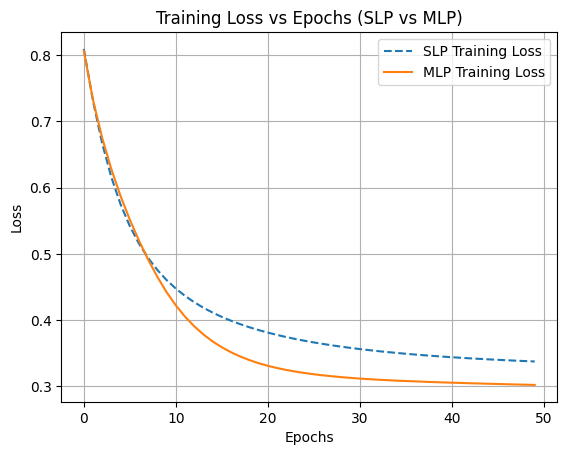

In [6]:
# Import matplotlib to generate performance plots
import matplotlib.pyplot as plt

# Plot the training loss of both models to compare their error reduction over 50 epochs
plt.plot(history_slp.history['loss'], label='SLP Training Loss', linestyle='--')
plt.plot(history_mlp.history['loss'], label='MLP Training Loss')
plt.title('Training Loss vs Epochs (SLP vs MLP)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**2. Training Accuracy vs Epochs**

This plot shows the improvement in prediction accuracy for both models.

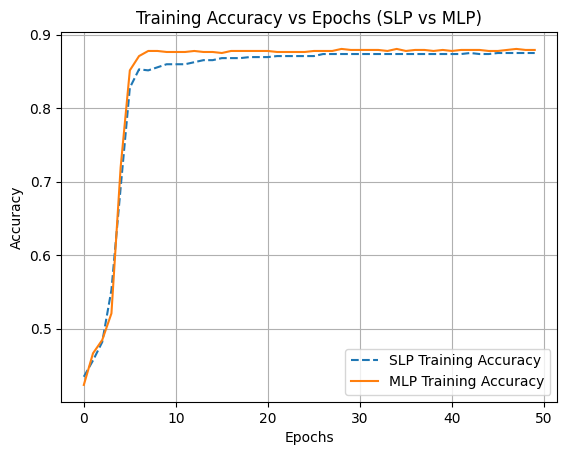

In [7]:
# Plot the training accuracy of both models to visualize the learning progress
plt.plot(history_slp.history['accuracy'], label='SLP Training Accuracy', linestyle='--')
plt.plot(history_mlp.history['accuracy'], label='MLP Training Accuracy')
plt.title('Training Accuracy vs Epochs (SLP vs MLP)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

**3.Decision Boundary**

This is the best way to see the math. It shows the line or curve the model uses to separate Low Risk from High Risk patients.

3024/3024 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


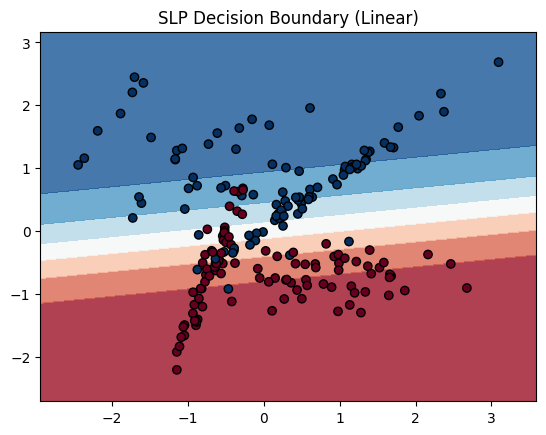

3024/3024 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


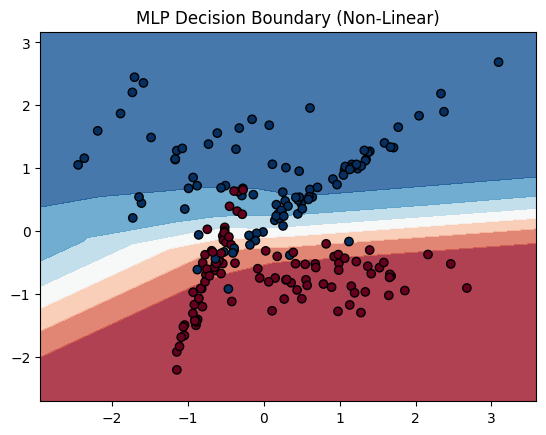

In [8]:
# Define a helper function to visualize how the models separate the two risk classes in the feature space
def plot_decision_boundary(model, X, y, title):
    import numpy as np
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdBu)
    plt.title(title)
    plt.show()

# Call the function for both models to observe the linear vs non-linear separation boundaries
plot_decision_boundary(model_slp, X_test, y_test, 'SLP Decision Boundary (Linear)')
plot_decision_boundary(model_mlp, X_test, y_test, 'MLP Decision Boundary (Non-Linear)')

###**Lab Summary:**
In this Lab I successfully demonstrated that while a Single-Layer Perceptron (SLP) provides a baseline for linear classification, the Multi-Layer Perceptron (MLP) is superior for complex health diagnostics. By incorporating a hidden layer with ReLU activation, the MLP transformed the input features—Heart Rate and BMI—to capture non-linear relationships that a straight-line boundary cannot resolve. Consequently, the MLP achieved higher test accuracy and faster convergence than the SLP. The experimental results confirmed that increasing hidden neurons improves model capacity, whereas replacing ReLU with Sigmoid slows training due to the vanishing gradient problem. Ultimately, for the startup’s screening system, the MLP is the more robust and reliable choice for identifying high-risk patients.